In [1]:
import pandas as pd

In [3]:
data=pd.read_csv('Mall_Customers.csv')

In [4]:
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [5]:
data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
data.drop('CustomerID',axis=1,inplace=True)

In [7]:
data

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [8]:
x=data[['Annual Income (k$)','Spending Score (1-100)']]

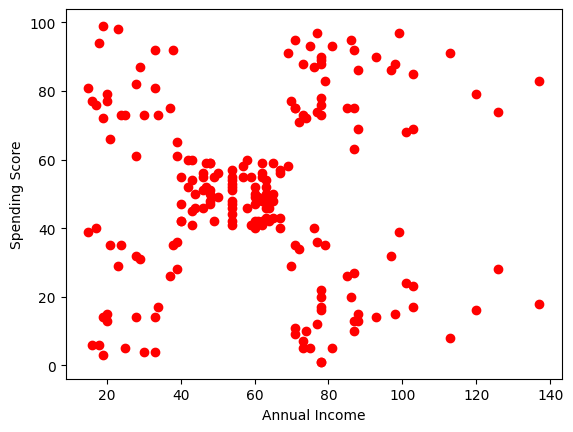

In [15]:
import matplotlib.pyplot as plt
plt.scatter(x['Annual Income (k$)'],x['Spending Score (1-100)'],color='red')
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

In [16]:
#find the number of cluster using Elbow Method
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
  kmean=KMeans(n_clusters=i,random_state=42)
  kmean.fit(x)
  wcss.append(kmean.inertia_)  

C:\Users\VISHVA.S\AppData\Local\Temp\ipykernel_3796\104405551.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


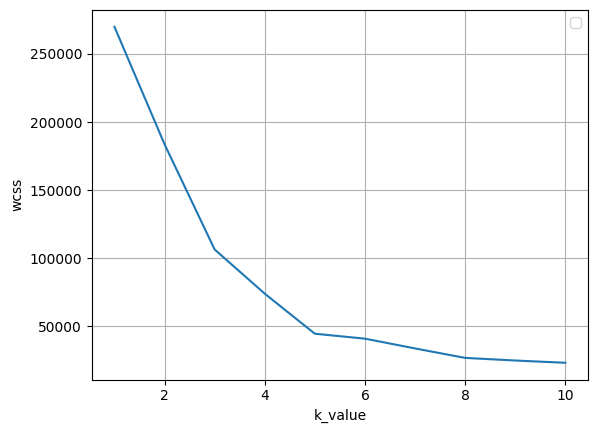

In [18]:
plt.plot(range(1,11,1),wcss)
plt.xlabel('k_value')
plt.ylabel('wcss')
plt.legend()
plt.grid()
plt.show()

In [19]:
#k=5 it is falling point 
kmean=KMeans(n_clusters=5,random_state=42)
y_pred=kmean.fit_predict(x)

In [21]:
data['cluster']=y_pred
data.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,Male,19,15,39,4
1,Male,21,15,81,2
2,Female,20,16,6,4
3,Female,23,16,77,2
4,Female,31,17,40,4


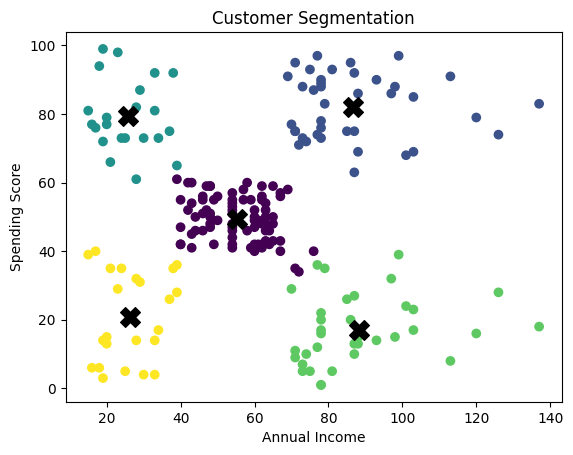

In [34]:
plt.scatter(
    x.iloc[:,0],
    x.iloc[:,1],
    c=y_pred
)

plt.scatter(
    kmean.cluster_centers_[:,0],
    kmean.cluster_centers_[:,1],
    s=200,
    marker='X',
    c='black'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")
plt.show()

In [42]:
data.groupby('cluster').mean(numeric_only=True)

,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [24]:
x.iloc[:,0]

0       15
1       15
2       16
3       16
4       17
      ... 
195    120
196    126
197    126
198    137
199    137
Name: Annual Income (k$), Length: 200, dtype: int64

In [25]:
x.iloc[:,1]

0      39
1      81
2       6
3      77
4      40
       ..
195    79
196    28
197    74
198    18
199    83
Name: Spending Score (1-100), Length: 200, dtype: int64

In [30]:
kmean.cluster_centers_[:,0]

array([55.2962963 , 86.53846154, 25.72727273, 88.2       , 26.30434783])

In [49]:
Annual_Income=int(input('enter the customer Annual Income '))
Spending_Score=int(input('ennter the Spending Score of a customer:'))
user_value=[Annual_Income,Spending_Score]
value=kmean.predict([user_value])[0]
cluster_Value={0:'Low Income, Low Spending',1:'High Income, High Spending',2:'Average Customers',3:'High Income, Low Spending',4:'Low Income, High Spending'}
print('the customer is belongs to:',cluster_Value[value])



the customer is belongs to: High Income, High Spending


c:\Users\VISHVA.S\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
